In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports, paths, helpers, load data

In [ ]:
import os
import gzip
import json
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
from IPython.display import display

# Ensure folders
os.makedirs("results", exist_ok=True)
os.makedirs("figs", exist_ok=True)

# ---------- Load helpers ----------

def parse_json_gz(path):
    with gzip.open(path, 'rb') as f:
        for line in f:
            yield json.loads(line)

def load_partial_json(path, max_lines=100000):
    data = []
    with gzip.open(path, 'rb') as f:
        for i, line in enumerate(f):
            if i >= max_lines:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

# ---------- Load sampled datasets ----------

electronics_df = load_partial_json('/content/drive/MyDrive/EECS4414_project_dataset/Electronics_5.json.gz', 100000)
beauty_df      = load_partial_json('/content/drive/MyDrive/EECS4414_project_dataset/All_Beauty_5.json.gz', 100000)
home_df        = load_partial_json('/content/drive/MyDrive/EECS4414_project_dataset/Home_and_Kitchen_5.json.gz', 100000)

print("(rows, columns)")
print("Electronics:", electronics_df.shape)
print("All_Beauty:", beauty_df.shape)
print("Home_and_Kitchen:", home_df.shape)

(rows, columns)
Electronics: (100000, 12)
All_Beauty: (5269, 12)
Home_and_Kitchen: (100000, 12)


# Build co-purchase graphs + GCC + basic stats

In [ ]:
# ---------- Graph construction ----------

def build_copurchase_graph(df, min_weight=2):
    """
    Undirected co-purchase graph:
    nodes: ASINs
    edge (i,j): at least min_weight users reviewed both i & j
    """
    user_reviews = defaultdict(set)
    for _, row in df.iterrows():
        user = row['reviewerID']
        asin = row['asin']
        user_reviews[user].add(asin)

    edge_weights = defaultdict(int)
    for products in user_reviews.values():
        if len(products) < 2:
            continue
        for a, b in combinations(sorted(products), 2):
            edge_weights[(a, b)] += 1

    G = nx.Graph()
    for (a, b), w in edge_weights.items():
        if w >= min_weight:
            G.add_edge(a, b, weight=w)
    return G

def extract_gcc(G):
    if G.number_of_nodes() == 0:
        return G.copy()
    if nx.is_connected(G):
        return G
    gcc_nodes = max(nx.connected_components(G), key=len)
    return G.subgraph(gcc_nodes).copy()

def graph_stats(G):
    V = G.number_of_nodes()
    E = G.number_of_edges()
    density = nx.density(G)
    avg_deg = (sum(dict(G.degree()).values()) / V) if V > 0 else 0.0
    return V, E, density, avg_deg

def print_graph_stats(G, name=""):
    V, E, density, avg_deg = graph_stats(G)
    print(f"Graph: {name}")
    print(" Nodes:", V)
    print(" Edges:", E)
    print(" Avg Degree:", avg_deg)
    print(" Density:", density)
    print()

def save_5core_stats(gcc_dict, path="results/5core_stats.csv"):
    rows = []
    for category, G in gcc_dict.items():
        V, E, density, avg_deg = graph_stats(G)
        rows.append({
            'category': category,
            'V': V,
            'E': E,
            'density': density,
            'avg_degree': avg_deg
        })
    pd.DataFrame(rows).to_csv(path, index=False)
    print(f"Saved GCC stats to {path}")

# ---------- Build graphs ----------

G_elec  = build_copurchase_graph(electronics_df)
G_beauty = build_copurchase_graph(beauty_df)
G_home  = build_copurchase_graph(home_df)

G_elec_gcc  = extract_gcc(G_elec)
G_beauty_gcc = extract_gcc(G_beauty)
G_home_gcc  = extract_gcc(G_home)

print_graph_stats(G_elec_gcc,  "Electronics GCC")
print_graph_stats(G_beauty_gcc,"All_Beauty GCC")
print_graph_stats(G_home_gcc,  "Home_and_Kitchen GCC")

gcc_dict = {
    "Electronics": G_elec_gcc,
    "All_Beauty": G_beauty_gcc,
    "Home_and_Kitchen": G_home_gcc
}
save_5core_stats(gcc_dict)

Graph: Electronics GCC
 Nodes: 720
 Edges: 3144
 Avg Degree: 8.733333333333333
 Density: 0.012146499768196569

Graph: All_Beauty GCC
 Nodes: 58
 Edges: 236
 Avg Degree: 8.137931034482758
 Density: 0.14277071990320628

Graph: Home_and_Kitchen GCC
 Nodes: 579
 Edges: 3849
 Avg Degree: 13.295336787564766
 Density: 0.023002312781253923

Saved GCC stats to results/5core_stats.csv


#  Edge timestamps + t* per category

In [ ]:
# ---------- Time metadata ----------

def compute_edge_timestamps(df, G):
    """
    For each edge (i,j) in G, assign earliest co-review time across users.
    """
    edge_times = defaultdict(list)
    user_reviews = defaultdict(list)

    for _, row in df.iterrows():
        user = row['reviewerID']
        asin = row['asin']
        ts = row['unixReviewTime']
        user_reviews[user].append((asin, ts))

    for _, item_times in user_reviews.items():
        if len(item_times) < 2:
            continue
        times = {}
        for asin, ts in item_times:
            # keep earliest review time per asin
            times[asin] = min(times.get(asin, ts), ts)
        items = sorted(times.keys())
        if len(items) < 2:
            continue
        for a, b in combinations(items, 2):
            if G.has_edge(a, b):
                t_ij = min(times[a], times[b])
                edge_times[(a, b)].append(t_ij)

    edge_timestamp = {e: min(ts_list) for e, ts_list in edge_times.items()}
    return edge_timestamp

def compute_t_star(edge_timestamp, quantile=80):
    ts = list(edge_timestamp.values())
    if not ts:
        return None
    return int(np.percentile(ts, quantile))

print("Computing edge timestamps...")

edge_ts_elec   = compute_edge_timestamps(electronics_df, G_elec_gcc)
edge_ts_beauty = compute_edge_timestamps(beauty_df,      G_beauty_gcc)
edge_ts_home   = compute_edge_timestamps(home_df,        G_home_gcc)

t_star_elec   = compute_t_star(edge_ts_elec)
t_star_beauty = compute_t_star(edge_ts_beauty)
t_star_home   = compute_t_star(edge_ts_home)

print("t* values (unix time):")
print(" Electronics:", t_star_elec)
print(" All_Beauty:", t_star_beauty)
print(" Home_and_Kitchen:", t_star_home)

Computing edge timestamps...
t* values (unix time):
 Electronics: 1384300800
 All_Beauty: 1452038400
 Home_and_Kitchen: 1370822400


# Time-based train/test split (warm) + train graphs

In [ ]:
def time_split_edges(G, edge_timestamps, t_star):
    """
    Time-based split:
    - Train: edges with t <= t_star
    - Test: edges with t > t_star AND both endpoints seen in train
    """
    E_train, E_test = [], []

    if t_star is None:
        return [], []

    for (u, v), t in edge_timestamps.items():
        if t <= t_star:
            E_train.append((u, v, G[u][v]))
        else:
            E_test.append((u, v, G[u][v]))

    train_nodes = {u for u, v, _ in E_train} | {v for u, v, _ in E_train}
    E_test_filtered = [(u, v, d) for (u, v, d) in E_test if u in train_nodes and v in train_nodes]

    return E_train, E_test_filtered

def build_graph_from_edges(edge_list):
    G = nx.Graph()
    for u, v, data in edge_list:
        G.add_edge(u, v, **data)
    return G

# ---------- Warm split per category ----------

E_train_elec,   E_test_elec   = time_split_edges(G_elec_gcc,   edge_ts_elec,   t_star_elec)
E_train_beauty, E_test_beauty = time_split_edges(G_beauty_gcc, edge_ts_beauty, t_star_beauty)
E_train_home,   E_test_home   = time_split_edges(G_home_gcc,   edge_ts_home,   t_star_home)

G_train_elec   = build_graph_from_edges(E_train_elec)
G_train_beauty = build_graph_from_edges(E_train_beauty)
G_train_home   = build_graph_from_edges(E_train_home)

print(" Electronics: Train =", len(E_train_elec),   "| Test =", len(E_test_elec))
print(" All_Beauty: Train =", len(E_train_beauty), "| Test =", len(E_test_beauty))
print(" Home_and_Kitchen: Train =", len(E_train_home),   "| Test =", len(E_test_home))

 Electronics: Train = 2517 | Test = 575
 All_Beauty: Train = 191 | Test = 33
 Home_and_Kitchen: Train = 3080 | Test = 723


# 2-hop candidate generation

In [ ]:
from tqdm import tqdm

def generate_candidates(G_train):
    """
    2-hop non-edge candidates for link prediction.
    """
    candidates = set()
    for node in tqdm(G_train.nodes(), desc="2-hop candidate gen"):
        neighbors = set(G_train[node])
        two_hop = set()
        for nbr in neighbors:
            two_hop |= set(G_train[nbr])
        two_hop -= neighbors
        two_hop.discard(node)
        for target in two_hop:
            if not G_train.has_edge(node, target):
                u, v = sorted((node, target))
                candidates.add((u, v))
    return list(candidates)

print("Generating candidates...")

candidates = {
    "Electronics": generate_candidates(G_train_elec),
    "All_Beauty": generate_candidates(G_train_beauty),
    "Home_and_Kitchen": generate_candidates(G_train_home),
}

for cat, cand in candidates.items():
    print(f" {cat}: {len(cand)} candidates")

Generating candidates...


2-hop candidate gen: 100%|██████████| 552/552 [00:00<00:00, 2829.42it/s]


 Electronics: 34308 candidates
 All_Beauty: 438 candidates
 Home_and_Kitchen: 42110 candidates


# Baseline scorers + unified evaluate_link_prediction (fixed)

In [ ]:
from sklearn.metrics import average_precision_score, roc_auc_score
import random

Ks = [10, 20, 50, 100, 200, 500]

# ---------- Baseline scoring functions ----------

def score_common_neighbors(G, u, v):
    return len(set(G[u]) & set(G[v]))

def score_jaccard(G, u, v):
    n_u = set(G[u])
    n_v = set(G[v])
    union = n_u | n_v
    if not union:
        return 0.0
    return len(n_u & n_v) / len(union)

def score_adamic_adar(G, u, v):
    return sum(1 / np.log(len(G[z])) for z in set(G[u]) & set(G[v]) if len(G[z]) > 1)

def score_preferential_attachment(G, u, v):
    return len(G[u]) * len(G[v])

baseline_funcs = {
    "CN": score_common_neighbors,
    "Jaccard": score_jaccard,
    "AA": score_adamic_adar,
    "PA": score_preferential_attachment,
}

# ---------- Evaluation ----------

def evaluate_link_prediction(G_train,
                             E_test,
                             candidates,
                             baseline_funcs,
                             category,
                             t_star,
                             seed=42):
    """
    Evaluate LP baselines:
    - balanced pos/neg (or all negs if fewer)
    - returns per-(baseline,K) metrics with proper t_star, neg_ratio
    """
    np.random.seed(seed)
    random.seed(seed)

    num_pos = len(E_test)
    num_cand = len(candidates)

    if num_pos == 0:
        print(f"No positive test edges for {category}, seed={seed}.")
        return []

    if num_cand == 0:
        print(f"No candidates for {category}, seed={seed}.")
        return []

    if num_cand < num_pos:
        print(f"{category}, seed={seed}: negatives<{num_pos}, using all {num_cand}.")
        negatives = candidates
    else:
        negatives = random.sample(candidates, num_pos)

    neg_ratio = len(negatives) / float(num_pos)

    all_results = []

    for baseline, scorer in baseline_funcs.items():
        y_true = []
        y_score = []

        # Positives
        for (u, v, _) in E_test:
            try:
                s = scorer(G_train, u, v)
            except Exception:
                s = 0.0
            y_score.append(s)
            y_true.append(1)

        # Negatives
        for (u, v) in negatives:
            try:
                s = scorer(G_train, u, v)
            except Exception:
                s = 0.0
            y_score.append(s)
            y_true.append(0)

        try:
            ap = average_precision_score(y_true, y_score)
            auc = roc_auc_score(y_true, y_score)
        except Exception:
            ap, auc = np.nan, np.nan

        order = np.argsort(y_score)[::-1]
        sorted_labels = np.array(y_true)[order]

        for K in Ks:
            if K > len(sorted_labels):
                continue
            p_at_k = float(np.mean(sorted_labels[:K]))
            all_results.append({
                "seed": seed,
                "category": category,
                "baseline": baseline,
                "K": K,
                "AP": ap,
                "AUC": auc,
                "P@K": p_at_k,
                "t_star": t_star,
                "num_pos": num_pos,
                "num_neg": len(negatives),
                "neg_ratio": neg_ratio,
            })

    return all_results

# Run warm evaluation for all categories + save eval_linkpred_all.csv

In [ ]:
categories = ["Electronics", "All_Beauty", "Home_and_Kitchen"]

graphs_train = {
    "Electronics": G_train_elec,
    "All_Beauty": G_train_beauty,
    "Home_and_Kitchen": G_train_home,
}
test_edges = {
    "Electronics": E_test_elec,
    "All_Beauty": E_test_beauty,
    "Home_and_Kitchen": E_test_home,
}
t_stars = {
    "Electronics": t_star_elec,
    "All_Beauty": t_star_beauty,
    "Home_and_Kitchen": t_star_home,
}
candidate_cache = candidates  # from Cell 5

all_results = []

for seed in [42, 43, 44, 45, 46]:
    for cat in categories:
        print(f"\n[WARM] {cat} | seed={seed}")
        G = graphs_train[cat]
        E_test = test_edges[cat]
        cand = candidate_cache[cat]
        t_star = t_stars[cat]

        res = evaluate_link_prediction(
            G_train=G,
            E_test=E_test,
            candidates=cand,
            baseline_funcs=baseline_funcs,
            category=cat,
            t_star=t_star,
            seed=seed
        )
        all_results.extend(res)

df_all = pd.DataFrame(all_results)
df_all.to_csv("results/eval_linkpred_all.csv", index=False)
print("Saved warm results to results/eval_linkpred_all.csv")
display(df_all.head())


[WARM] Electronics | seed=42

[WARM] All_Beauty | seed=42

[WARM] Home_and_Kitchen | seed=42

[WARM] Electronics | seed=43

[WARM] All_Beauty | seed=43

[WARM] Home_and_Kitchen | seed=43

[WARM] Electronics | seed=44

[WARM] All_Beauty | seed=44

[WARM] Home_and_Kitchen | seed=44

[WARM] Electronics | seed=45

[WARM] All_Beauty | seed=45

[WARM] Home_and_Kitchen | seed=45

[WARM] Electronics | seed=46

[WARM] All_Beauty | seed=46

[WARM] Home_and_Kitchen | seed=46
Saved warm results to results/eval_linkpred_all.csv


,seed,category,baseline,K,AP,AUC,P@K,t_star,num_pos,num_neg,neg_ratio
0,42,Electronics,CN,10,0.709724,0.664876,0.900,1384300800,575,575,1.0
1,42,Electronics,CN,20,0.709724,0.664876,0.950,1384300800,575,575,1.0
2,42,Electronics,CN,50,0.709724,0.664876,0.940,1384300800,575,575,1.0
3,42,Electronics,CN,100,0.709724,0.664876,0.880,1384300800,575,575,1.0
4,42,Electronics,CN,200,0.709724,0.664876,0.875,1384300800,575,575,1.0


# Cold-start split + cold evaluation + eval_linkpred_cold.csv

In [ ]:
# ---------- Cold-start splits ----------

def time_split_edges_allow_cold(G, edge_timestamps, t_star):
    """
    Train: t <= t_star
    Test: t > t_star (include even if nodes unseen -> enables cold-start edges)
    """
    E_train, E_test = [], []
    if t_star is None:
        return [], []
    for (u, v), t in edge_timestamps.items():
        if t <= t_star:
            E_train.append((u, v, G[u][v]))
        else:
            E_test.append((u, v, G[u][v]))
    return E_train, E_test

E_train_elec_cold,   E_test_elec_cold   = time_split_edges_allow_cold(G_elec_gcc,   edge_ts_elec,   t_star_elec)
E_train_beauty_cold, E_test_beauty_cold = time_split_edges_allow_cold(G_beauty_gcc, edge_ts_beauty, t_star_beauty)
E_train_home_cold,   E_test_home_cold   = time_split_edges_allow_cold(G_home_gcc,   edge_ts_home,   t_star_home)

G_train_elec_cold   = build_graph_from_edges(E_train_elec_cold)
G_train_beauty_cold = build_graph_from_edges(E_train_beauty_cold)
G_train_home_cold   = build_graph_from_edges(E_train_home_cold)

graphs_train_cold = {
    "Electronics": G_train_elec_cold,
    "All_Beauty": G_train_beauty_cold,
    "Home_and_Kitchen": G_train_home_cold,
}
test_edges_cold = {
    "Electronics": E_test_elec_cold,
    "All_Beauty": E_test_beauty_cold,
    "Home_and_Kitchen": E_test_home_cold,
}
t_stars_cold = t_stars  # same t_star

def get_cold_edges(E_test, G_train):
    """
    Test edges where at least one endpoint is unseen in G_train.
    """
    train_nodes = set(G_train.nodes())
    return [
        (u, v, d)
        for (u, v, d) in E_test
        if (u not in train_nodes) or (v not in train_nodes)
    ]

def generate_cold_candidates(G_train, cold_nodes):
    """
    For each cold node, connect to all train nodes as candidate non-edges.
    """
    candidates = set()
    train_nodes = set(G_train.nodes)
    for n in tqdm(cold_nodes, desc="cold-nodes"):
        for m in train_nodes:
            if n == m:
                continue
            u, v = sorted((n, m))
            if not G_train.has_edge(u, v):
                candidates.add((u, v))
    return list(candidates)

cold_results = []

for seed in [42, 43, 44, 45, 46]:
    np.random.seed(seed)
    random.seed(seed)

    for cat in categories:
        print(f"\n[COLD] {cat} | seed={seed}")
        G_train_c = graphs_train_cold[cat]
        E_test_c = test_edges_cold[cat]
        t_star = t_stars_cold[cat]

        cold_edges = get_cold_edges(E_test_c, G_train_c)
        print(f" cold edges: {len(cold_edges)} / {len(E_test_c)} total")

        if not cold_edges:
            print("No cold-start edges, skip.")
            continue

        cold_nodes = {
            u for (u, v, _) in cold_edges if u not in G_train_c.nodes
        } | {
            v for (u, v, _) in cold_edges if v not in G_train_c.nodes
        }
        print(f" cold nodes: {len(cold_nodes)}")

        if not cold_nodes:
            print("No cold-start nodes, skip.")
            continue

        cold_candidates = generate_cold_candidates(G_train_c, cold_nodes)
        print(f" candidates: {len(cold_candidates)}")

        res = evaluate_link_prediction(
            G_train=G_train_c,
            E_test=cold_edges,
            candidates=cold_candidates,
            baseline_funcs=baseline_funcs,
            category=cat,
            t_star=t_star,
            seed=seed
        )
        cold_results.extend(res)

df_cold = pd.DataFrame(cold_results)
df_cold.to_csv("results/eval_linkpred_cold.csv", index=False)
print("Saved cold-start results to results/eval_linkpred_cold.csv")
display(df_cold.head())


[COLD] Electronics | seed=42
 cold edges: 52 / 627 total
 cold nodes: 34


cold-nodes: 100%|██████████| 34/34 [00:00<00:00, 216.45it/s]


 candidates: 23324

[COLD] All_Beauty | seed=42
 cold edges: 12 / 45 total
 cold nodes: 3


cold-nodes: 100%|██████████| 3/3 [00:00<00:00, 3395.28it/s]


 candidates: 165

[COLD] Home_and_Kitchen | seed=42
 cold edges: 46 / 769 total
 cold nodes: 27


...

cold-nodes: 100%|██████████| 3/3 [00:00<00:00, 10010.27it/s]


 candidates: 165

[COLD] Home_and_Kitchen | seed=46
 cold edges: 46 / 769 total
 cold nodes: 27


cold-nodes: 100%|██████████| 27/27 [00:00<00:00, 1583.35it/s]


 candidates: 14904
Saved cold-start results to results/eval_linkpred_cold.csv


,seed,category,baseline,K,AP,AUC,P@K,t_star,num_pos,num_neg,neg_ratio
0,42,Electronics,CN,10,0.5,0.5,0.00,1384300800,52,52,1.0
1,42,Electronics,CN,20,0.5,0.5,0.00,1384300800,52,52,1.0
2,42,Electronics,CN,50,0.5,0.5,0.00,1384300800,52,52,1.0
3,42,Electronics,CN,100,0.5,0.5,0.48,1384300800,52,52,1.0
4,42,Electronics,Jaccard,10,0.5,0.5,0.00,1384300800,52,52,1.0


# Aggregated CSVs: overall_metrics.csv + coldstart_metrics.csv

In [ ]:
# ---------- overall_metrics.csv (warm only) ----------

df_all = pd.read_csv("results/eval_linkpred_all.csv")

rows = []
for (cat, base, K), g in df_all.groupby(["category", "baseline", "K"]):
    seeds = sorted(g["seed"].unique())
    rows.append({
        "category": cat,
        "baseline": base,
        "K": int(K),
        "auc_mean": g["AUC"].mean(),
        "auc_std": g["AUC"].std(ddof=1),
        "ap_mean": g["AP"].mean(),
        "ap_std": g["AP"].std(ddof=1),
        "p_at_k_mean": g["P@K"].mean(),
        "p_at_k_std": g["P@K"].std(ddof=1),
        "neg_ratio": g["neg_ratio"].iloc[0],
        "seeds": ",".join(str(s) for s in seeds),
        "t_star_min": g["t_star"].min(),
        "t_star_max": g["t_star"].max(),
    })

overall_df = pd.DataFrame(rows).sort_values(["category", "baseline", "K"])
overall_df.to_csv("results/overall_metrics.csv", index=False)
print("Saved results/overall_metrics.csv")
display(overall_df.head())

# coldstart_metrics.csv (warm + cold)

df_all["split"] = "warm"
df_cold = pd.read_csv("results/eval_linkpred_cold.csv")
df_cold["split"] = "cold"

df_combined = pd.concat([df_all, df_cold], ignore_index=True)

rows = []
for (cat, base, K, split), g in df_combined.groupby(["category", "baseline", "K", "split"]):
    seeds = sorted(g["seed"].unique())
    rows.append({
        "category": cat,
        "baseline": base,
        "K": int(K),
        "split": split,
        "auc_mean": g["AUC"].mean(),
        "auc_std": g["AUC"].std(ddof=1),
        "ap_mean": g["AP"].mean(),
        "ap_std": g["AP"].std(ddof=1),
        "p_at_k_mean": g["P@K"].mean(),
        "p_at_k_std": g["P@K"].std(ddof=1),
        "neg_ratio": g["neg_ratio"].iloc[0] if "neg_ratio" in g else np.nan,
        "seeds": ",".join(str(s) for s in seeds),
    })

coldstart_metrics = pd.DataFrame(rows).sort_values(
    ["category", "baseline", "K", "split"]
)
coldstart_metrics.to_csv("results/coldstart_metrics.csv", index=False)
print("Saved results/coldstart_metrics.csv")
display(coldstart_metrics.head())

Saved results/overall_metrics.csv


,category,baseline,K,auc_mean,auc_std,ap_mean,ap_std,p_at_k_mean,p_at_k_std,neg_ratio,seeds,t_star_min,t_star_max
0,All_Beauty,AA,10,0.711570,0.045324,0.750272,0.034600,0.940,0.089443,1.0,"42,43,44,45,46",1452038400,1452038400
1,All_Beauty,AA,20,0.711570,0.045324,0.750272,0.034600,0.780,0.044721,1.0,"42,43,44,45,46",1452038400,1452038400
2,All_Beauty,AA,50,0.711570,0.045324,0.750272,0.034600,0.556,0.021909,1.0,"42,43,44,45,46",1452038400,1452038400
3,All_Beauty,CN,10,0.652066,0.042454,0.675642,0.032279,0.880,0.083666,1.0,"42,43,44,45,46",1452038400,1452038400
4,All_Beauty,CN,20,0.652066,0.042454,0.675642,0.032279,0.610,0.054772,1.0,"42,43,44,45,46",1452038400,1452038400


Saved results/coldstart_metrics.csv


,category,baseline,K,split,auc_mean,auc_std,ap_mean,ap_std,p_at_k_mean,p_at_k_std,neg_ratio,seeds
0,All_Beauty,AA,10,cold,0.50000,0.000000,0.500000,0.0000,0.000,0.000000,1.0,"42,43,44,45,46"
1,All_Beauty,AA,10,warm,0.71157,0.045324,0.750272,0.0346,0.940,0.089443,1.0,"42,43,44,45,46"
2,All_Beauty,AA,20,cold,0.50000,0.000000,0.500000,0.0000,0.400,0.000000,1.0,"42,43,44,45,46"
3,All_Beauty,AA,20,warm,0.71157,0.045324,0.750272,0.0346,0.780,0.044721,1.0,"42,43,44,45,46"
4,All_Beauty,AA,50,warm,0.71157,0.045324,0.750272,0.0346,0.556,0.021909,1.0,"42,43,44,45,46"


# Graph construction & GCC stats

,category,V,E,density,avg_degree
0,Electronics,720,3144,0.012146,8.733333
1,All_Beauty,58,236,0.142771,8.137931
2,Home_and_Kitchen,579,3849,0.023002,13.295337


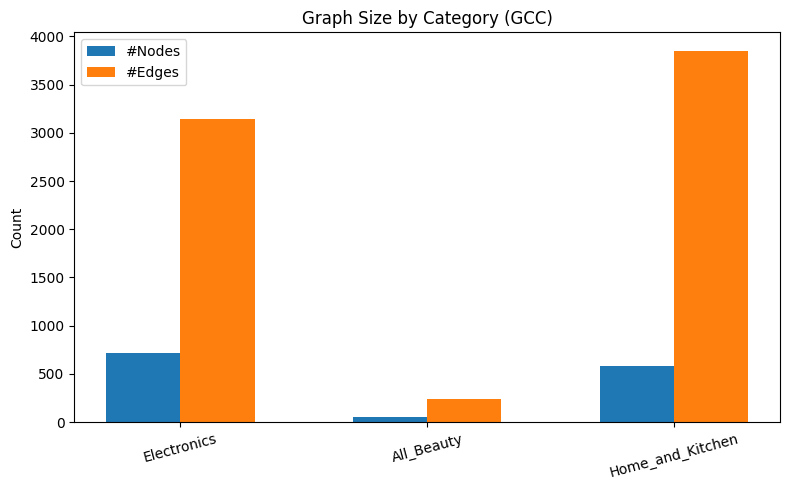

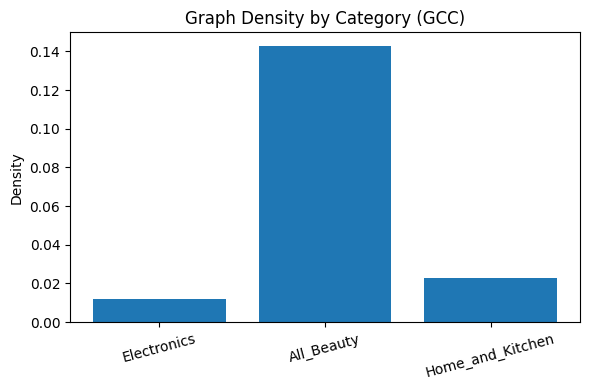

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

stats_df = pd.read_csv("results/5core_stats.csv")
display(stats_df)

# --- Fig 1: Nodes & Edges ---
plt.figure(figsize=(8, 5))
x = range(len(stats_df))

plt.bar([i - 0.15 for i in x], stats_df["V"], width=0.3, label="#Nodes")
plt.bar([i + 0.15 for i in x], stats_df["E"], width=0.3, label="#Edges")

plt.xticks(x, stats_df["category"], rotation=15)
plt.ylabel("Count")
plt.title("Graph Size by Category (GCC)")
plt.legend()
plt.tight_layout()
plt.savefig("figs/graph_stats_nodes_edges.png", dpi=300)
plt.show()

# --- Fig 2 (optional): Density ---
plt.figure(figsize=(6, 4))
plt.bar(stats_df["category"], stats_df["density"])
plt.xticks(rotation=15)
plt.ylabel("Density")
plt.title("Graph Density by Category (GCC)")
plt.tight_layout()
plt.savefig("figs/graph_stats_density.png", dpi=300)
plt.show()

# (Timestamps + t★) graph

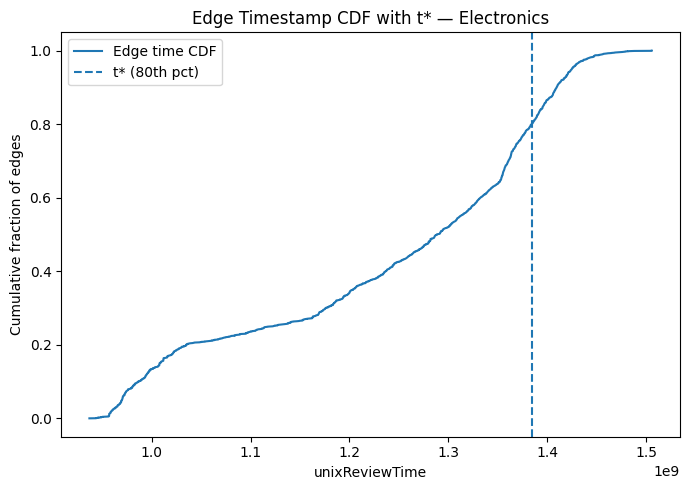

Saved figs/edge_time_cdf_Electronics.png


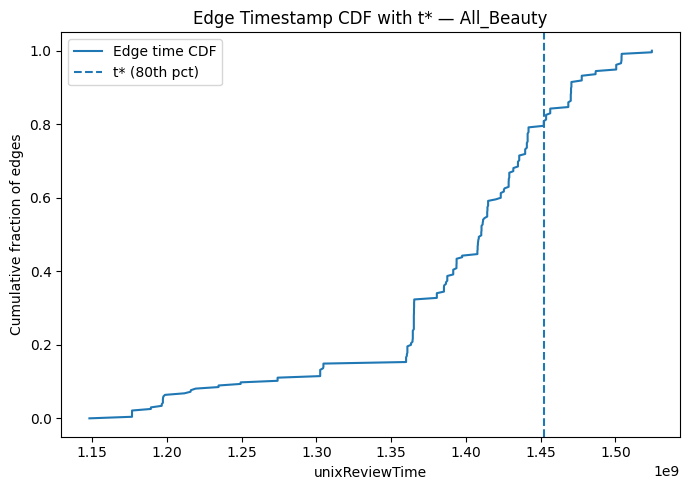

Saved figs/edge_time_cdf_All_Beauty.png


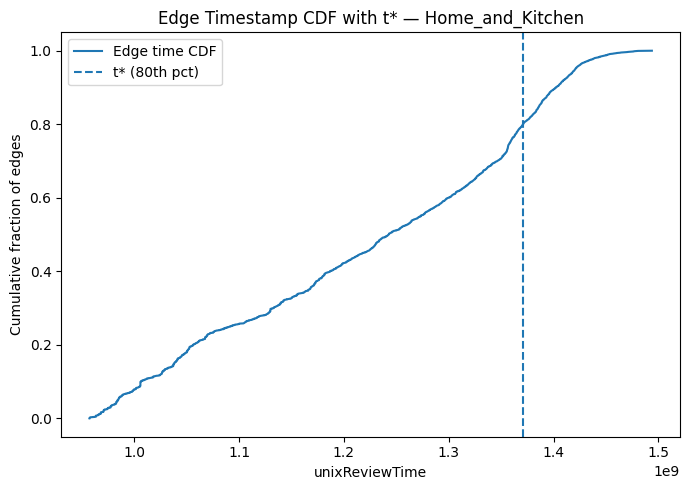

Saved figs/edge_time_cdf_Home_and_Kitchen.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_edge_time_cdf(edge_ts, t_star, category):
    if not edge_ts:
        print(f"No timestamps for {category}, skipping.")
        return
    ts = np.array(list(edge_ts.values()))
    ts_sorted = np.sort(ts)
    y = np.linspace(0, 1, len(ts_sorted))

    plt.figure(figsize=(7, 5))
    plt.plot(ts_sorted, y, label="Edge time CDF")
    if t_star is not None:
        plt.axvline(t_star, linestyle="--", label=f"t* (80th pct)")
    plt.xlabel("unixReviewTime")
    plt.ylabel("Cumulative fraction of edges")
    plt.title(f"Edge Timestamp CDF with t* — {category}")
    plt.legend()
    plt.tight_layout()
    fname = f"figs/edge_time_cdf_{category}.png"
    plt.savefig(fname, dpi=300)
    plt.show()
    print("Saved", fname)

plot_edge_time_cdf(edge_ts_elec,   t_star_elec,   "Electronics")
plot_edge_time_cdf(edge_ts_beauty, t_star_beauty, "All_Beauty")
plot_edge_time_cdf(edge_ts_home,   t_star_home,   "Home_and_Kitchen")

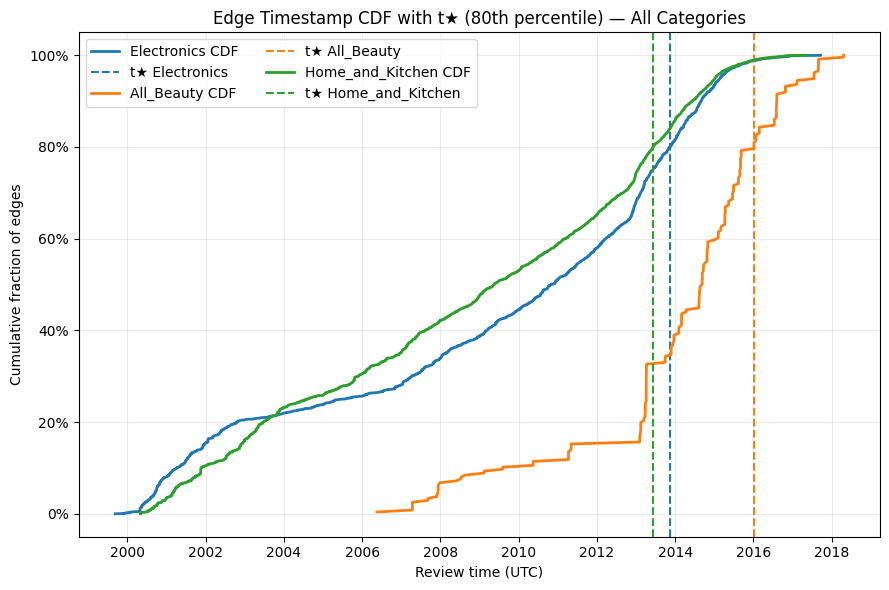

Saved figs/edge_time_cdf_all.png and figs/edge_time_cdf_all.svg


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

# Helper: turn a dict {(u,v): ts} -> sorted timestamps & CDF y
def _cdf_from_edge_ts(edge_ts):
    if not edge_ts:
        return None, None
    ts = np.array(list(edge_ts.values()), dtype=np.int64)
    ts_sorted = np.sort(ts)
    y = np.arange(1, len(ts_sorted) + 1) / float(len(ts_sorted))
    x_dt = pd.to_datetime(ts_sorted, unit='s')
    return x_dt, y

series = [
    ("Electronics",      edge_ts_elec,   t_star_elec),
    ("All_Beauty",       edge_ts_beauty, t_star_beauty),
    ("Home_and_Kitchen", edge_ts_home,   t_star_home),
]

plt.figure(figsize=(9, 6))

lines_for_legend = []
labels_for_legend = []

for cat, edge_ts, t_star in series:
    x_dt, y = _cdf_from_edge_ts(edge_ts)
    if x_dt is None:
        print(f"No timestamps for {cat}; skipping.")
        continue

    # Plot CDF
    [line] = plt.plot(x_dt, y, linewidth=2, label=f"{cat} CDF")
    lines_for_legend.append(line)
    labels_for_legend.append(f"{cat} CDF")

    # Plot t★ as a vertical line in the same color
    if t_star is not None:
        t_dt = pd.to_datetime(t_star, unit='s')
        vline = plt.axvline(t_dt, linestyle="--", linewidth=1.5, color=line.get_color(), label=f"t★ {cat}")
        lines_for_legend.append(vline)
        labels_for_legend.append(f"t★ {cat}")

# Axes formatting
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
locator = mdates.AutoDateLocator()
plt.gca().xaxis.set_major_locator(locator)
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

plt.xlabel("Review time (UTC)")
plt.ylabel("Cumulative fraction of edges")
plt.title("Edge Timestamp CDF with t★ (80th percentile) — All Categories")
plt.grid(True, alpha=0.25)

# Legend (two columns to keep it compact)
plt.legend(lines_for_legend, labels_for_legend, ncols=2, frameon=True)
plt.tight_layout()

# Save
out_png = "figs/edge_time_cdf_all.png"
out_svg = "figs/edge_time_cdf_all.svg"
plt.savefig(out_png, dpi=300)
plt.savefig(out_svg)
plt.show()
print(f"Saved {out_png} and {out_svg}")

# (Train/Test split summary)

,category,train,test
0,Electronics,2517,575
1,All_Beauty,191,33
2,Home_and_Kitchen,3080,723


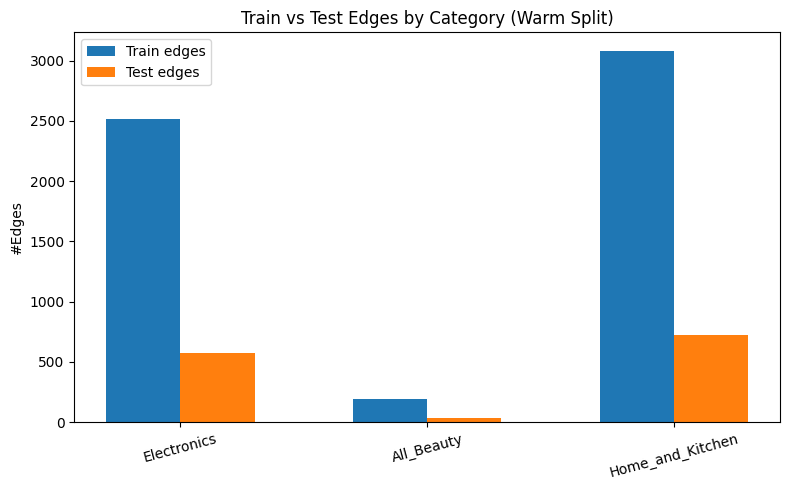

In [ ]:
import matplotlib.pyplot as plt

split_stats = pd.DataFrame([
    {"category": "Electronics",      "train": len(E_train_elec),   "test": len(E_test_elec)},
    {"category": "All_Beauty",       "train": len(E_train_beauty), "test": len(E_test_beauty)},
    {"category": "Home_and_Kitchen", "train": len(E_train_home),   "test": len(E_test_home)},
])

display(split_stats)

plt.figure(figsize=(8, 5))
x = range(len(split_stats))
plt.bar([i - 0.15 for i in x], split_stats["train"], width=0.3, label="Train edges")
plt.bar([i + 0.15 for i in x], split_stats["test"],  width=0.3, label="Test edges")
plt.xticks(x, split_stats["category"], rotation=15)
plt.ylabel("#Edges")
plt.title("Train vs Test Edges by Category (Warm Split)")
plt.legend()
plt.tight_layout()
plt.savefig("figs/train_test_edges.png", dpi=300)
plt.show()

# (Candidate generation)

,category,candidates
0,Electronics,34308
1,All_Beauty,438
2,Home_and_Kitchen,42110


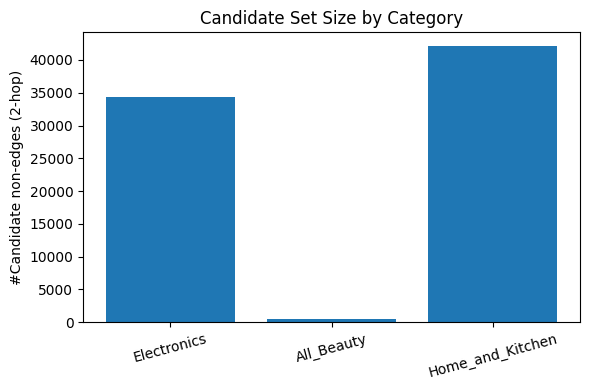

In [ ]:
import matplotlib.pyplot as plt

cand_stats = pd.DataFrame([
    {"category": cat, "candidates": len(cand)}
    for cat, cand in candidates.items()
])

display(cand_stats)

plt.figure(figsize=(6, 4))
plt.bar(cand_stats["category"], cand_stats["candidates"])
plt.xticks(rotation=15)
plt.ylabel("#Candidate non-edges (2-hop)")
plt.title("Candidate Set Size by Category")
plt.tight_layout()
plt.savefig("figs/candidates_per_category.png", dpi=300)
plt.show()

# Warm evaluation + overall_metrics

**P@K curves per category**

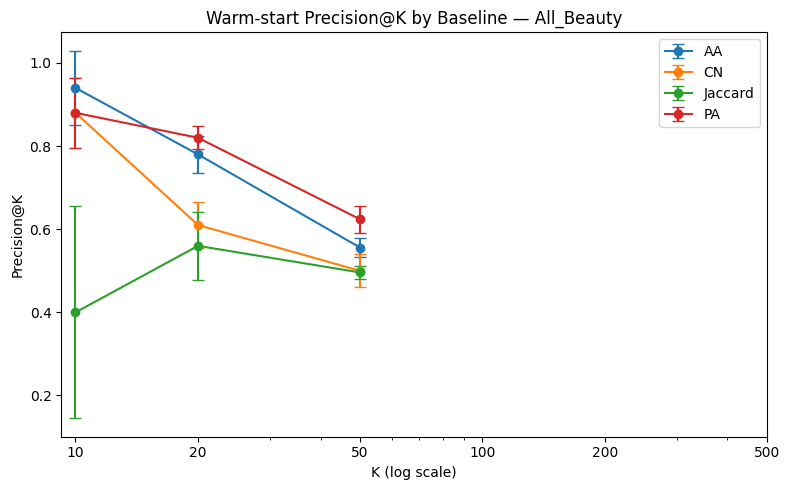

Saved figs/patk_warm_All_Beauty.png


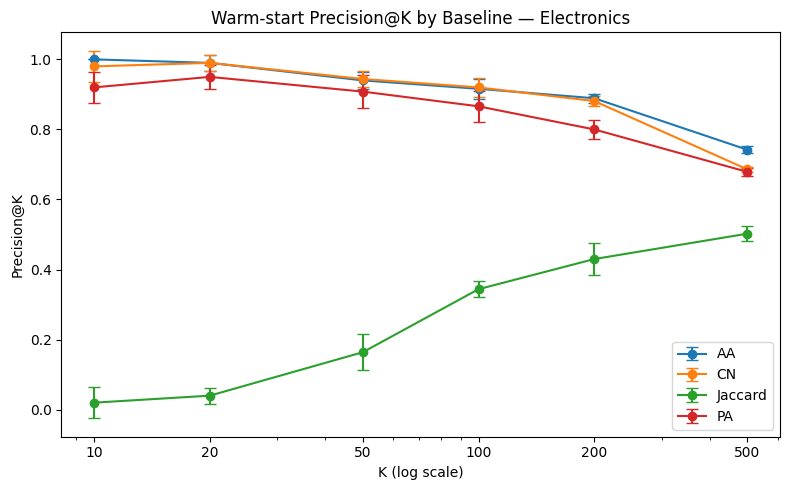

Saved figs/patk_warm_Electronics.png


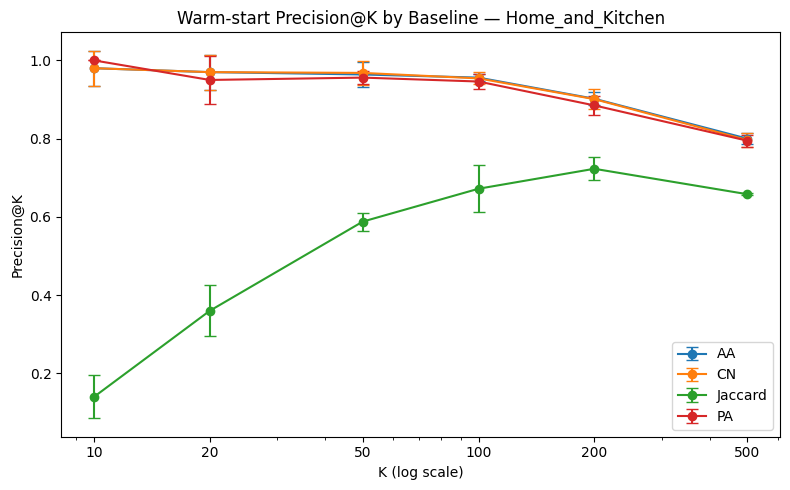

Saved figs/patk_warm_Home_and_Kitchen.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

overall = pd.read_csv("results/overall_metrics.csv")

for cat in overall["category"].unique():
    subset = overall[overall["category"] == cat]

    plt.figure(figsize=(8, 5))
    for baseline in subset["baseline"].unique():
        g = subset[subset["baseline"] == baseline]
        plt.errorbar(
            g["K"],
            g["p_at_k_mean"],
            yerr=g["p_at_k_std"],
            marker="o",
            capsize=4,
            label=baseline
        )

    plt.xscale("log")
    plt.xticks([10, 20, 50, 100, 200, 500], [10, 20, 50, 100, 200, 500])
    plt.xlabel("K (log scale)")
    plt.ylabel("Precision@K")
    plt.title(f"Warm-start Precision@K by Baseline — {cat}")
    plt.legend()
    plt.tight_layout()
    fname = f"figs/patk_warm_{cat}.png".replace(" ", "_")
    plt.savefig(fname, dpi=300)
    plt.show()
    print("Saved", fname)

**AUC/AP bar chart**

,category,baseline,auc_mean,ap_mean
0,All_Beauty,AA,0.711570,0.750272
1,All_Beauty,CN,0.652066,0.675642
2,All_Beauty,Jaccard,0.524334,0.523646
3,All_Beauty,PA,0.813407,0.810707
4,Electronics,AA,0.696637,0.759865
5,Electronics,CN,0.657627,0.708990
6,Electronics,Jaccard,0.446262,0.459700
7,Electronics,PA,0.719779,0.719781
8,Home_and_Kitchen,AA,0.739947,0.781346
9,Home_and_Kitchen,CN,0.723324,0.751878


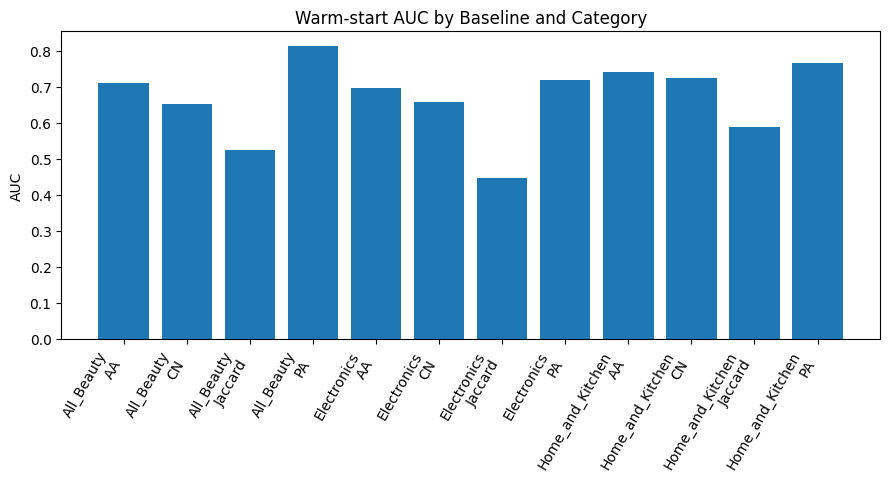

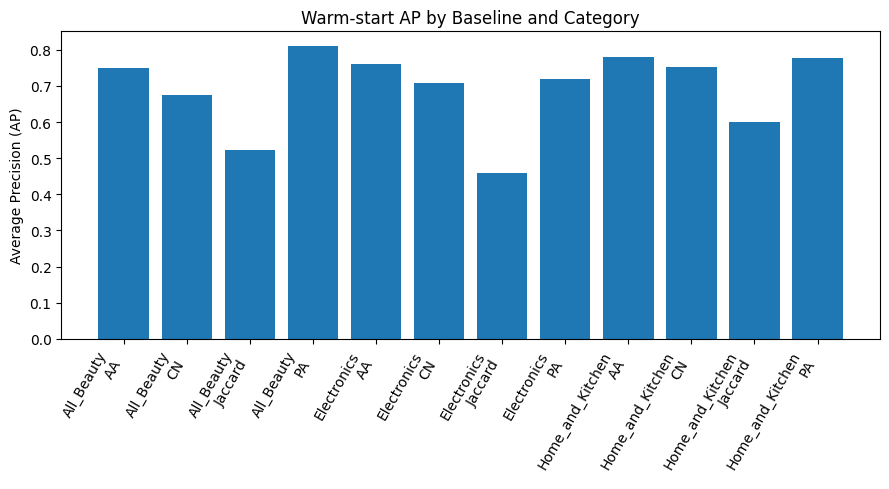

In [ ]:
# Aggregate over all K: metrics are same per seed, but we'll just take mean over rows
agg = overall.groupby(["category", "baseline"]).agg(
    auc_mean=("auc_mean", "mean"),
    ap_mean=("ap_mean", "mean")
).reset_index()

display(agg)

plt.figure(figsize=(9, 5))
x_labels = [f"{c}\n{b}" for c, b in zip(agg["category"], agg["baseline"])]
x = range(len(agg))

plt.bar(x, agg["auc_mean"])
plt.xticks(x, x_labels, rotation=60, ha="right")
plt.ylabel("AUC")
plt.title("Warm-start AUC by Baseline and Category")
plt.tight_layout()
plt.savefig("figs/auc_warm.png", dpi=300)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x, agg["ap_mean"])
plt.xticks(x, x_labels, rotation=60, ha="right")
plt.ylabel("Average Precision (AP)")
plt.title("Warm-start AP by Baseline and Category")
plt.tight_layout()
plt.savefig("figs/ap_warm.png", dpi=300)
plt.show()

#(Cold-start evaluation + coldstart_metrics)

No K=100 data for All_Beauty, skipping.


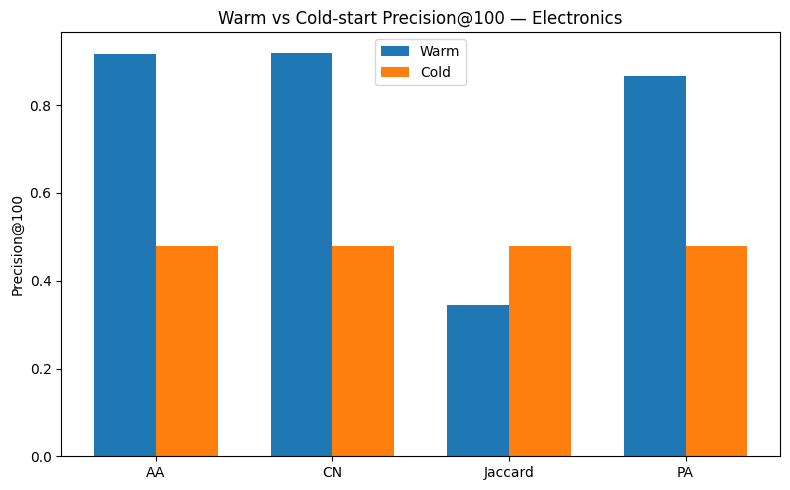

Saved figs/p100_warm_vs_cold_Electronics.png


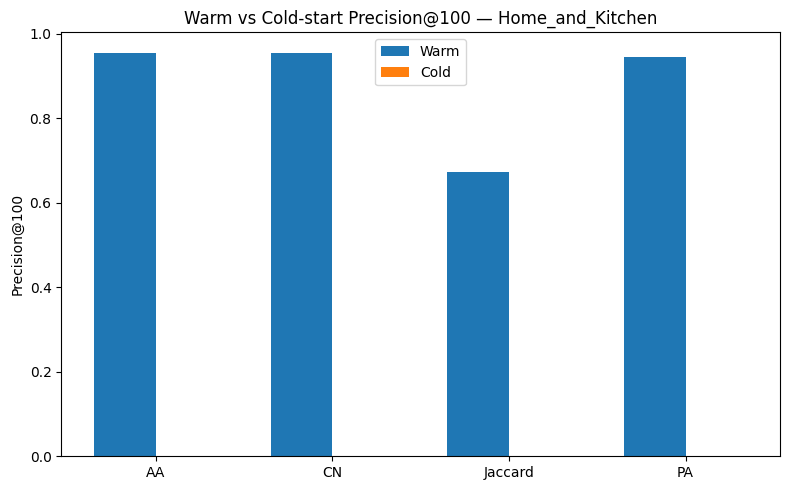

Saved figs/p100_warm_vs_cold_Home_and_Kitchen.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

coldmetrics = pd.read_csv("results/coldstart_metrics.csv")

K_focus = 100  # typical choice; adjust if your test supports it

for cat in coldmetrics["category"].unique():
    sub = coldmetrics[(coldmetrics["category"] == cat) & (coldmetrics["K"] == K_focus)]
    if sub.empty:
        print(f"No K={K_focus} data for {cat}, skipping.")
        continue

    baselines = sub["baseline"].unique()
    warm_vals = []
    cold_vals = []

    for b in baselines:
        warm_row = sub[(sub["baseline"] == b) & (sub["split"] == "warm")]
        cold_row = sub[(sub["baseline"] == b) & (sub["split"] == "cold")]

        warm_vals.append(warm_row["p_at_k_mean"].iloc[0] if not warm_row.empty else 0.0)
        cold_vals.append(cold_row["p_at_k_mean"].iloc[0] if not cold_row.empty else 0.0)

    x = np.arange(len(baselines))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, warm_vals, width, label="Warm")
    plt.bar(x + width/2, cold_vals, width, label="Cold")
    plt.xticks(x, baselines)
    plt.ylabel(f"Precision@{K_focus}")
    plt.title(f"Warm vs Cold-start Precision@{K_focus} — {cat}")
    plt.legend()
    plt.tight_layout()
    fname = f"figs/p{K_focus}_warm_vs_cold_{cat}.png".replace(" ", "_")
    plt.savefig(fname, dpi=300)
    plt.show()
    print("Saved", fname)

,category,baseline,delta_p_at_k
0,Electronics,AA,-0.436
1,Electronics,CN,-0.440
2,Electronics,Jaccard,0.136
3,Electronics,PA,-0.386


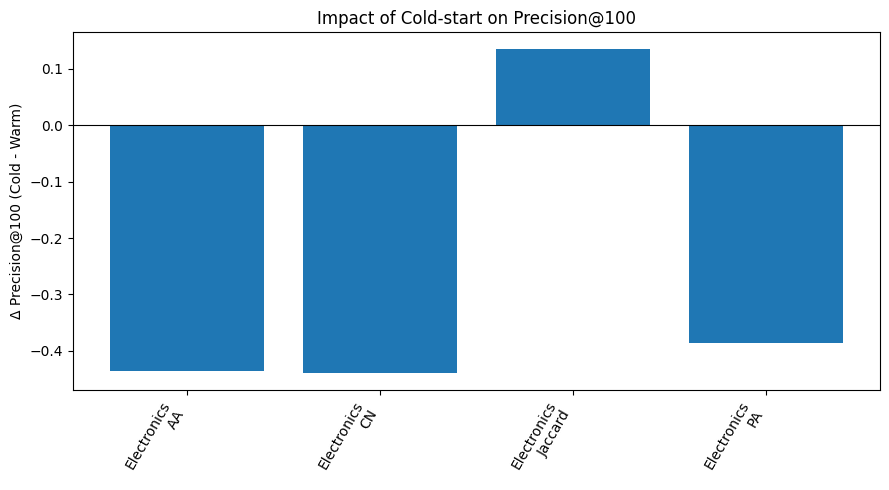

In [ ]:
rows = []
for (cat, base, K), g in coldmetrics.groupby(["category", "baseline", "K"]):
    if K != K_focus:
        continue
    warm = g[g["split"] == "warm"]
    cold = g[g["split"] == "cold"]
    if warm.empty or cold.empty:
        continue
    rows.append({
        "category": cat,
        "baseline": base,
        "delta_p_at_k": float(cold["p_at_k_mean"].iloc[0] - warm["p_at_k_mean"].iloc[0])
    })

delta_df = pd.DataFrame(rows)
display(delta_df)

plt.figure(figsize=(9, 5))
labels = [f"{r.category}\n{r.baseline}" for _, r in delta_df.iterrows()]
x = range(len(delta_df))
plt.bar(x, delta_df["delta_p_at_k"])
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel(f"Δ Precision@{K_focus} (Cold - Warm)")
plt.title("Impact of Cold-start on Precision@100")
plt.tight_layout()
plt.savefig("figs/delta_p100_coldstart.png", dpi=300)
plt.show()

# Final Part Modification

RUNTIME MEASUREMENT: GRAPH CONSTRUCTION

In [ ]:
import time
import pandas as pd

graph_runtimes = []

print("Measuring graph construction time...\n")

# Electronics
start = time.time()
_ = build_copurchase_graph(electronics_df)
t_elec = time.time() - start
print(f"Electronics graph build time: {t_elec:.4f} seconds")
graph_runtimes.append(["Electronics", t_elec])

# All Beauty
start = time.time()
_ = build_copurchase_graph(beauty_df)
t_beauty = time.time() - start
print(f"All Beauty graph build time: {t_beauty:.4f} seconds")
graph_runtimes.append(["All_Beauty", t_beauty])

# Home & Kitchen
start = time.time()
_ = build_copurchase_graph(home_df)
t_home = time.time() - start
print(f"Home & Kitchen graph build time: {t_home:.4f} seconds")
graph_runtimes.append(["Home_and_Kitchen", t_home])

# Save results
df_graph_runtime = pd.DataFrame(graph_runtimes, columns=["category", "seconds"])
df_graph_runtime.to_csv("results/runtime_graph.csv", index=False)

print("\nSaved graph construction runtime to results/runtime_graph.csv")
df_graph_runtime

Measuring graph construction time...

Electronics graph build time: 4.7052 seconds
All Beauty graph build time: 0.2244 seconds
Home & Kitchen graph build time: 6.2570 seconds

Saved graph construction runtime to results/runtime_graph.csv


,category,seconds
0,Electronics,4.705164
1,All_Beauty,0.224379
2,Home_and_Kitchen,6.257031


# RUNTIME MEASUREMENT: CANDIDATE GENERATION

In [ ]:
import time
import pandas as pd

candidate_runtimes = []

print("\nMeasuring 2-hop candidate generation time...\n")

# Electronics
start = time.time()
_ = generate_candidates(G_train_elec)
t_elec_cand = time.time() - start
print(f"Electronics candidate generation time: {t_elec_cand:.4f} seconds")
candidate_runtimes.append(["Electronics", t_elec_cand])

# All Beauty
start = time.time()
_ = generate_candidates(G_train_beauty)
t_beauty_cand = time.time() - start
print(f"All Beauty candidate generation time: {t_beauty_cand:.4f} seconds")
candidate_runtimes.append(["All_Beauty", t_beauty_cand])

# Home & Kitchen
start = time.time()
_ = generate_candidates(G_train_home)
t_home_cand = time.time() - start
print(f"Home & Kitchen candidate generation time: {t_home_cand:.4f} seconds")
candidate_runtimes.append(["Home_and_Kitchen", t_home_cand])

# Save results
df_candidate_runtime = pd.DataFrame(candidate_runtimes, columns=["category", "seconds"])
df_candidate_runtime.to_csv("results/runtime_candidates.csv", index=False)

print("\nSaved candidate generation runtime to results/runtime_candidates.csv")
df_candidate_runtime


Measuring 2-hop candidate generation time...



2-hop candidate gen: 100%|██████████| 686/686 [00:00<00:00, 1068.74it/s]


Electronics candidate generation time: 0.6872 seconds


2-hop candidate gen: 100%|██████████| 55/55 [00:00<00:00, 6786.30it/s]


All Beauty candidate generation time: 0.0283 seconds


2-hop candidate gen: 100%|██████████| 552/552 [00:00<00:00, 1233.97it/s]

Home & Kitchen candidate generation time: 0.4645 seconds

Saved candidate generation runtime to results/runtime_candidates.csv


,category,seconds
0,Electronics,0.687244
1,All_Beauty,0.028344
2,Home_and_Kitchen,0.464479


# Baseline Scoring Runtime:
For each category (Electronics, Beauty, Home):
	1.	Randomly sample 2,000 candidate edges
	2.	Measure runtime for:
	•	Common Neighbors
	•	Jaccard
	•	Adamic–Adar
	•	Preferential Attachment
	3.	Save results to:
results/runtime_baselines.csv

In [ ]:
import time
import random
import pandas as pd

baseline_runtimes = []

print("\nMeasuring baseline scoring runtime...\n")

def measure_baseline_runtime(G_train, cand_list, category_name, num_samples=2000):
    # sample edges from candidate list
    sample_edges = random.sample(cand_list, min(num_samples, len(cand_list)))
    results = []

    # For each baseline
    for name, scorer in baseline_funcs.items():
        start = time.time()
        for (u, v) in sample_edges:
            try:
                _ = scorer(G_train, u, v)
            except:
                pass
        t = time.time() - start
        print(f"{category_name} — {name} runtime ({len(sample_edges)} edges): {t:.4f} seconds")
        results.append([category_name, name, t])

    return results


# Electronics
baseline_runtimes.extend(
    measure_baseline_runtime(G_train_elec, candidates["Electronics"], "Electronics")
)

# All Beauty
baseline_runtimes.extend(
    measure_baseline_runtime(G_train_beauty, candidates["All_Beauty"], "All_Beauty")
)

# Home & Kitchen
baseline_runtimes.extend(
    measure_baseline_runtime(G_train_home, candidates["Home_and_Kitchen"], "Home_and_Kitchen")
)

# Save to CSV
df_baseline_runtime = pd.DataFrame(
    baseline_runtimes,
    columns=["category", "baseline", "seconds"]
)
df_baseline_runtime.to_csv("results/runtime_baselines.csv", index=False)

print("\nSaved baseline scoring runtime to results/runtime_baselines.csv")
df_baseline_runtime


Measuring baseline scoring runtime...

Electronics — CN runtime (2000 edges): 0.0118 seconds
Electronics — Jaccard runtime (2000 edges): 0.0129 seconds
Electronics — AA runtime (2000 edges): 0.0295 seconds
Electronics — PA runtime (2000 edges): 0.0024 seconds
All_Beauty — CN runtime (438 edges): 0.0009 seconds
All_Beauty — Jaccard runtime (438 edges): 0.0012 seconds
All_Beauty — AA runtime (438 edges): 0.0052 seconds
All_Beauty — PA runtime (438 edges): 0.0004 seconds
Home_and_Kitchen — CN runtime (2000 edges): 0.0111 seconds
Home_and_Kitchen — Jaccard runtime (2000 edges): 0.0156 seconds
Home_and_Kitchen — AA runtime (2000 edges): 0.0296 seconds
Home_and_Kitchen — PA runtime (2000 edges): 0.0023 seconds

Saved baseline scoring runtime to results/runtime_baselines.csv


,category,baseline,seconds
0,Electronics,CN,0.011828
1,Electronics,Jaccard,0.012930
2,Electronics,AA,0.029495
3,Electronics,PA,0.002358
4,All_Beauty,CN,0.000927
5,All_Beauty,Jaccard,0.001178
6,All_Beauty,AA,0.005171
7,All_Beauty,PA,0.000435
8,Home_and_Kitchen,CN,0.011133
9,Home_and_Kitchen,Jaccard,0.015628


# Warm vs Cold Visual Comparison
we will illustrate it with plots.

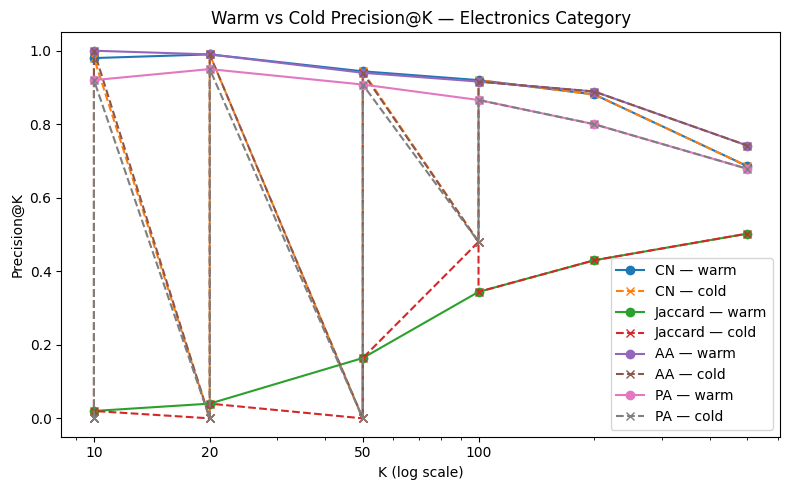

Saved warm vs cold comparison figure to figs/warm_vs_cold_electronics.png


In [ ]:



import pandas as pd
import matplotlib.pyplot as plt

# Load aggregated metrics
warm = pd.read_csv("results/overall_metrics.csv")
cold = pd.read_csv("results/coldstart_metrics.csv")

Ks = [10, 20, 50, 100]  # values guaranteed to exist

plt.figure(figsize=(8, 5))

baselines = ["CN", "Jaccard", "AA", "PA"]

for b in baselines:
    # Warm subset
    w = warm[(warm["category"] == "Electronics") & (warm["baseline"] == b)]
    # Cold subset
    c = cold[(cold["category"] == "Electronics") & (cold["baseline"] == b)]

    # Only plot values that exist (especially for small datasets)
    if len(w) > 0:
        plt.plot(
            w["K"],
            w["p_at_k_mean"],
            marker="o",
            label=f"{b} — warm"
        )
    if len(c) > 0:
        plt.plot(
            c["K"],
            c["p_at_k_mean"],
            marker="x",
            linestyle="--",
            label=f"{b} — cold"
        )

plt.xscale("log")
plt.xticks(Ks, Ks)
plt.xlabel("K (log scale)")
plt.ylabel("Precision@K")
plt.title("Warm vs Cold Precision@K — Electronics Category")
plt.legend()
plt.tight_layout()

# Save output
plt.savefig("figs/warm_vs_cold_electronics.png", dpi=300)
plt.show()

print("Saved warm vs cold comparison figure to figs/warm_vs_cold_electronics.png")

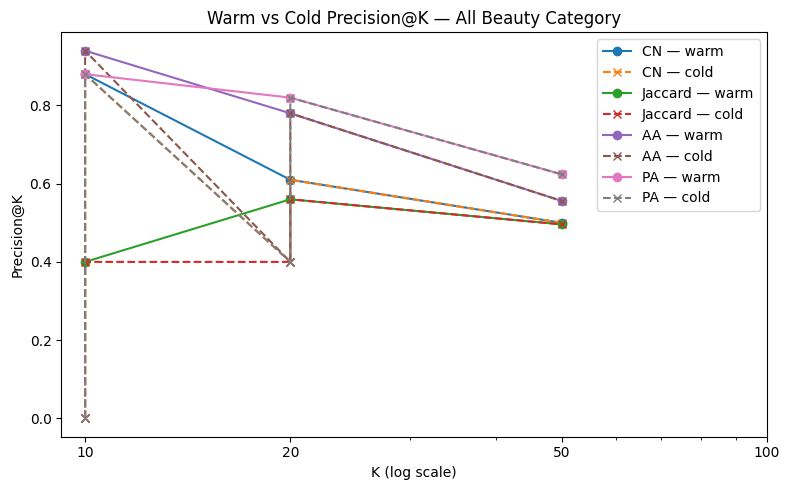

Saved warm vs cold comparison to figs/warm_vs_cold_beauty.png


In [ ]:
#WARM vs COLD PRECISION@K — ALL BEAUTY
import pandas as pd
import matplotlib.pyplot as plt

warm = pd.read_csv("results/overall_metrics.csv")
cold = pd.read_csv("results/coldstart_metrics.csv")

Ks = [10, 20, 50, 100]
baselines = ["CN", "Jaccard", "AA", "PA"]

plt.figure(figsize=(8, 5))

for b in baselines:
    w = warm[(warm["category"] == "All_Beauty") & (warm["baseline"] == b)]
    c = cold[(cold["category"] == "All_Beauty") & (cold["baseline"] == b)]

    if len(w) > 0:
        plt.plot(w["K"], w["p_at_k_mean"], marker='o', label=f"{b} — warm")
    if len(c) > 0:
        plt.plot(c["K"], c["p_at_k_mean"], marker='x', linestyle='--', label=f"{b} — cold")

plt.xscale("log")
plt.xticks(Ks, Ks)
plt.xlabel("K (log scale)")
plt.ylabel("Precision@K")
plt.title("Warm vs Cold Precision@K — All Beauty Category")
plt.legend()
plt.tight_layout()

plt.savefig("figs/warm_vs_cold_beauty.png", dpi=300)
plt.show()

print("Saved warm vs cold comparison to figs/warm_vs_cold_beauty.png")

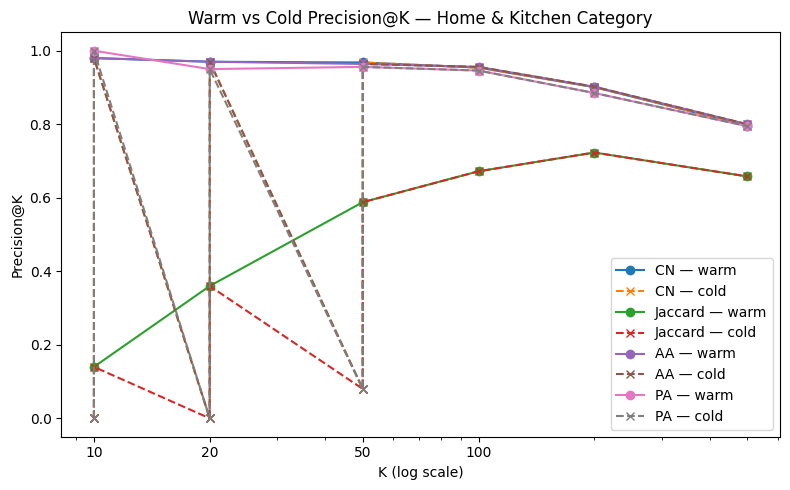

Saved warm vs cold comparison to figs/warm_vs_cold_home.png


In [ ]:

# WARM vs COLD PRECISION@K — HOME & KITCHEN

plt.figure(figsize=(8, 5))

for b in baselines:
    w = warm[(warm["category"] == "Home_and_Kitchen") & (warm["baseline"] == b)]
    c = cold[(cold["category"] == "Home_and_Kitchen") & (cold["baseline"] == b)]

    if len(w) > 0:
        plt.plot(w["K"], w["p_at_k_mean"], marker='o', label=f"{b} — warm")
    if len(c) > 0:
        plt.plot(c["K"], c["p_at_k_mean"], marker='x', linestyle='--', label=f"{b} — cold")

plt.xscale("log")
plt.xticks(Ks, Ks)
plt.xlabel("K (log scale)")
plt.ylabel("Precision@K")
plt.title("Warm vs Cold Precision@K — Home & Kitchen Category")
plt.legend()
plt.tight_layout()

plt.savefig("figs/warm_vs_cold_home.png", dpi=300)
plt.show()

print("Saved warm vs cold comparison to figs/warm_vs_cold_home.png")

# Bar Chart: Number of Cold Test Edges per Category

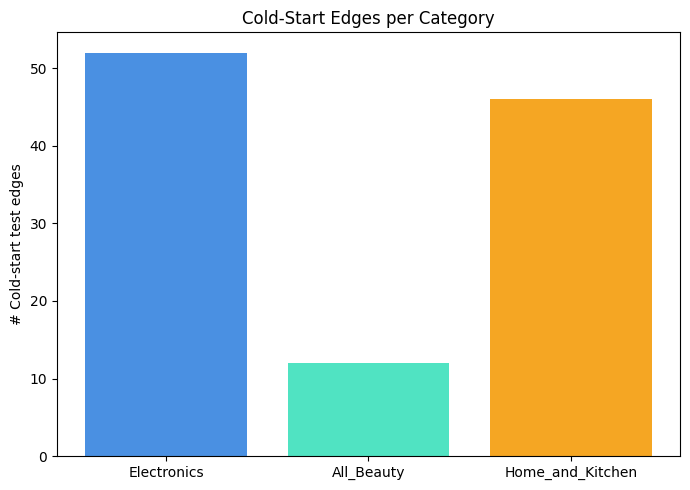

Cold-start edges: {'Electronics': 52, 'All_Beauty': 12, 'Home_and_Kitchen': 46}
Saved bar chart to figs/cold_edges_per_category.png


In [ ]:



import matplotlib.pyplot as plt

cold_edges_count = {
    "Electronics": len(E_test_elec_cold) - len(E_test_elec),
    "All_Beauty": len(E_test_beauty_cold) - len(E_test_beauty),
    "Home_and_Kitchen": len(E_test_home_cold) - len(E_test_home)
}

plt.figure(figsize=(7,5))
plt.bar(cold_edges_count.keys(), cold_edges_count.values(), color=['#4a90e2','#50e3c2','#f5a623'])
plt.ylabel("# Cold-start test edges")
plt.title("Cold-Start Edges per Category")

plt.tight_layout()
plt.savefig("figs/cold_edges_per_category.png", dpi=300)
plt.show()

print("Cold-start edges:", cold_edges_count)
print("Saved bar chart to figs/cold_edges_per_category.png")

# Table: Number of Cold Nodes per Category

In [ ]:



cold_nodes_stats = []

# Electronics
cold_nodes_elec = {
    u for (u, v, _) in E_test_elec_cold if u not in G_train_elec_cold.nodes
} | {
    v for (u, v, _) in E_test_elec_cold if v not in G_train_elec_cold.nodes
}
cold_nodes_stats.append(["Electronics", len(cold_nodes_elec)])

# All Beauty
cold_nodes_beauty = {
    u for (u, v, _) in E_test_beauty_cold if u not in G_train_beauty_cold.nodes
} | {
    v for (u, v, _) in E_test_beauty_cold if v not in G_train_beauty_cold.nodes
}
cold_nodes_stats.append(["All_Beauty", len(cold_nodes_beauty)])

# Home & Kitchen
cold_nodes_home = {
    u for (u, v, _) in E_test_home_cold if u not in G_train_home_cold.nodes
} | {
    v for (u, v, _) in E_test_home_cold if v not in G_train_home_cold.nodes
}
cold_nodes_stats.append(["Home_and_Kitchen", len(cold_nodes_home)])

df_cold_nodes = pd.DataFrame(cold_nodes_stats, columns=["category", "cold_nodes"])
df_cold_nodes.to_csv("results/cold_nodes.csv", index=False)

print("Cold-start nodes per category:")
display(df_cold_nodes)

print("Saved cold-start node table to results/cold_nodes.csv")

Cold-start nodes per category:


,category,cold_nodes
0,Electronics,34
1,All_Beauty,3
2,Home_and_Kitchen,27


Saved cold-start node table to results/cold_nodes.csv


# Extract Top Predicted Edges
For each category (Electronics, Beauty, Home & Kitchen):

Extract top-20 predicted edges for:

	* Common Neighbors (CN)
	* Jaccard
	* Adamic–Adar (AA)
	* Preferential Attachment (PA)

In [ ]:
#Helper function to extract top predictions
def get_top_predictions(G_train, candidates, scorer, top_k=20):
    scored = []
    for (u, v) in candidates:
        try:
            s = scorer(G_train, u, v)
        except:
            s = 0.0
        scored.append((u, v, s))

    scored.sort(key=lambda x: x[2], reverse=True)
    return scored[:top_k]

In [ ]:
#Generate top-20 predicted edges for each baseline and category
import pandas as pd
import os

os.makedirs("results/top_predictions", exist_ok=True)

categories_map = {
    "Electronics": (G_train_elec, candidates["Electronics"]),
    "All_Beauty": (G_train_beauty, candidates["All_Beauty"]),
    "Home_and_Kitchen": (G_train_home, candidates["Home_and_Kitchen"])
}

for category, (G_train_cat, cand_cat) in categories_map.items():
    print(f"\nProcessing category: {category}")

    for baseline_name, scorer in baseline_funcs.items():
        top_k = get_top_predictions(G_train_cat, cand_cat, scorer, top_k=20)

        df_top = pd.DataFrame(top_k, columns=["u", "v", "score"])

        outpath = f"results/top_predictions/top20_{baseline_name}_{category}.csv"
        df_top.to_csv(outpath, index=False)

        print(f"Saved: {outpath}")

print("\nAll top-20 prediction files saved under results/top_predictions/")


Processing category: Electronics
Saved: results/top_predictions/top20_CN_Electronics.csv
Saved: results/top_predictions/top20_Jaccard_Electronics.csv
Saved: results/top_predictions/top20_AA_Electronics.csv
Saved: results/top_predictions/top20_PA_Electronics.csv

Processing category: All_Beauty
Saved: results/top_predictions/top20_CN_All_Beauty.csv
Saved: results/top_predictions/top20_Jaccard_All_Beauty.csv
Saved: results/top_predictions/top20_AA_All_Beauty.csv
Saved: results/top_predictions/top20_PA_All_Beauty.csv

Processing category: Home_and_Kitchen
Saved: results/top_predictions/top20_CN_Home_and_Kitchen.csv
Saved: results/top_predictions/top20_Jaccard_Home_and_Kitchen.csv
Saved: results/top_predictions/top20_AA_Home_and_Kitchen.csv
Saved: results/top_predictions/top20_PA_Home_and_Kitchen.csv

All top-20 prediction files saved under results/top_predictions/


In [ ]:

# Synthetic Graph (Barabási–Albert) for Sanity Check

import networkx as nx
import random
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

print("\nGenerating synthetic Barabási–Albert graph (n=2000, m=5)...")

# Build BA graph
BA = nx.barabasi_albert_graph(2000, 5)
G_ba = nx.Graph()
G_ba.add_edges_from(BA.edges())

print("Total edges:", G_ba.number_of_edges())

# Create a fake temporal split: 50% train, 50% test
edges = list(G_ba.edges())
random.shuffle(edges)

mid = len(edges) // 2
train_edges = edges[:mid]
test_edges = edges[mid:]

# Build G_train
G_ba_train = nx.Graph()
G_ba_train.add_edges_from(train_edges)

print("Train edges:", len(train_edges))
print("Test edges:", len(test_edges))


Generating synthetic Barabási–Albert graph (n=2000, m=5)...
Total edges: 9975
Train edges: 4987
Test edges: 4988


In [ ]:
# Sample negative examples equal to #test edges
all_nodes = list(G_ba_train.nodes())
neg_candidates = []

while len(neg_candidates) < len(test_edges):
    u, v = random.sample(all_nodes, 2)
    if not G_ba_train.has_edge(u, v):
        neg_candidates.append((u, v))

print("Negative candidates sampled:", len(neg_candidates))

Negative candidates sampled: 4988


In [ ]:
def eval_baseline_synthetic(G_train, test_edges, neg_edges, scorer):
    scores = []
    labels = []

    # Positives
    for (u, v) in test_edges:
        try:
            s = scorer(G_train, u, v)
        except:
            s = 0
        scores.append(s)
        labels.append(1)

    # Negatives
    for (u, v) in neg_edges:
        try:
            s = scorer(G_train, u, v)
        except:
            s = 0
        scores.append(s)
        labels.append(0)

    auc = roc_auc_score(labels, scores)
    ap = average_precision_score(labels, scores)
    return auc, ap


synthetic_results = []

for bname, scorer in baseline_funcs.items():
    auc, ap = eval_baseline_synthetic(G_ba_train, test_edges, neg_candidates, scorer)
    synthetic_results.append([bname, auc, ap])
    print(f"{bname}: AUC={auc:.4f}, AP={ap:.4f}")

# Save results
df_synth = pd.DataFrame(synthetic_results, columns=["baseline", "AUC", "AP"])
df_synth.to_csv("results/synthetic_baseline_results.csv", index=False)

print("\nSaved synthetic experiment results to results/synthetic_baseline_results.csv")
df_synth

CN: AUC=0.5279, AP=0.5235
Jaccard: AUC=0.5271, AP=0.5082
AA: AUC=0.5279, AP=0.5264
PA: AUC=0.6706, AP=0.7092

Saved synthetic experiment results to results/synthetic_baseline_results.csv


,baseline,AUC,AP
0,CN,0.527908,0.523503
1,Jaccard,0.527061,0.508165
2,AA,0.527890,0.526376
3,PA,0.670630,0.709212


In [ ]:
#Unified Runtime Summary Table
import pandas as pd

print("\nLoading runtime data files...\n")

df_graph_rt = pd.read_csv("results/runtime_graph.csv")
df_cand_rt  = pd.read_csv("results/runtime_candidates.csv")
df_base_rt  = pd.read_csv("results/runtime_baselines.csv")

print("Files loaded successfully.")

# --- Create unified summary ---
summary = {
    "graph_build_time": df_graph_rt,
    "candidate_generation_time": df_cand_rt,
    "baseline_scoring_time": df_base_rt,
}

# --- Write summary to human-readable text file ---
out_path = "results/summary_runtime.txt"

with open(out_path, "w") as f:
    for section, df in summary.items():
        f.write(f"===== {section.upper()} =====\n")
        f.write(df.to_string())
        f.write("\n\n")

print(f"\n Saved unified runtime summary to {out_path}")

# Display DataFrames as final verification
print("\n=== Graph Build Times ===")
display(df_graph_rt)

print("\n=== Candidate Generation Times ===")
display(df_cand_rt)

print("\n=== Baseline Scoring Times ===")
display(df_base_rt)


Loading runtime data files...

Files loaded successfully.

 Saved unified runtime summary to results/summary_runtime.txt

=== Graph Build Times ===


,category,seconds
0,Electronics,4.705164
1,All_Beauty,0.224379
2,Home_and_Kitchen,6.257031



=== Candidate Generation Times ===


,category,seconds
0,Electronics,0.093434
1,All_Beauty,0.012990
2,Home_and_Kitchen,0.133632



=== Baseline Scoring Times ===


,category,baseline,seconds
0,Electronics,CN,0.011828
1,Electronics,Jaccard,0.012930
2,Electronics,AA,0.029495
3,Electronics,PA,0.002358
4,All_Beauty,CN,0.000927
5,All_Beauty,Jaccard,0.001178
6,All_Beauty,AA,0.005171
7,All_Beauty,PA,0.000435
8,Home_and_Kitchen,CN,0.011133
9,Home_and_Kitchen,Jaccard,0.015628


In [ ]:

# Unified Runtime Summary Table

import pandas as pd

print("\nLoading runtime data files...\n")

df_graph_rt = pd.read_csv("results/runtime_graph.csv")
df_cand_rt  = pd.read_csv("results/runtime_candidates.csv")
df_base_rt  = pd.read_csv("results/runtime_baselines.csv")

print("Files loaded successfully.")

# --- Create unified summary ---
summary = {
    "graph_build_time": df_graph_rt,
    "candidate_generation_time": df_cand_rt,
    "baseline_scoring_time": df_base_rt,
}

# --- Write summary to human-readable text file ---
out_path = "results/summary_runtime.txt"

with open(out_path, "w") as f:
    for section, df in summary.items():
        f.write(f"===== {section.upper()} =====\n")
        f.write(df.to_string())
        f.write("\n\n")

print(f"\nSaved unified runtime summary to {out_path}")

# Display DataFrames as final verification
print("\n=== Graph Build Times ===")
display(df_graph_rt)

print("\n=== Candidate Generation Times ===")
display(df_cand_rt)

print("\n=== Baseline Scoring Times ===")
display(df_base_rt)


Loading runtime data files...

Files loaded successfully.

Saved unified runtime summary to results/summary_runtime.txt

=== Graph Build Times ===


,category,seconds
0,Electronics,4.705164
1,All_Beauty,0.224379
2,Home_and_Kitchen,6.257031



=== Candidate Generation Times ===


,category,seconds
0,Electronics,0.093434
1,All_Beauty,0.012990
2,Home_and_Kitchen,0.133632



=== Baseline Scoring Times ===


,category,baseline,seconds
0,Electronics,CN,0.011828
1,Electronics,Jaccard,0.012930
2,Electronics,AA,0.029495
3,Electronics,PA,0.002358
4,All_Beauty,CN,0.000927
5,All_Beauty,Jaccard,0.001178
6,All_Beauty,AA,0.005171
7,All_Beauty,PA,0.000435
8,Home_and_Kitchen,CN,0.011133
9,Home_and_Kitchen,Jaccard,0.015628


In [ ]:
import pandas as pd

baselines = ["AA", "CN", "Jaccard", "PA"]

for baseline in baselines:
    file_path = f"results/top_predictions/top20_{baseline}_Electronics.csv"

    print(f"\nTop 10 Predictions — {baseline} (Electronics):")
    try:
        df = pd.read_csv(file_path)
        print(df.head(10))  # Show only top 10
    except FileNotFoundError:
        print(f"File not found: {file_path}")


Top 10 Predictions — AA (Electronics):
            u           v     score
0  B00004T8R2  B0000510R4  7.258227
1  B000065BP9  B000067RC4  6.257823
2  B00001P4ZH  B00004Z5M1  6.236187
3  B00004Z5CP  B000067S60  5.909273
4  B000067RTB  B000068O4N  5.892548
5  B00004ZCJI  B00005ATMB  5.755116
6  B00004ZCJJ  B00005ATMB  5.755116
7  B00004SABB  B0000668YX  5.468670
8  B00004Z5CP  B000065BPB  5.422700
9  B00004T8R2  B000068O4N  5.401691

Top 10 Predictions — CN (Electronics):
            u           v  score
0  B00004T8R2  B0000510R4     24
1  B00004Z5CP  B000067S60     21
2  B000065BP9  B000067RC4     21
3  B00001P4ZH  B00004Z5M1     20
4  B00004SABB  B0000668YX     19
5  B00004Z5CP  B000065BPB     19
6  B0000668YX  B000068O4N     18
7  B000065BP9  B0000668YX     18
8  B00004ZCJI  B00005ATMB     18
9  B00004T8R2  B000068O4N     18

Top 10 Predictions — Jaccard (Electronics):
            u           v  score
0  B00004TX77  B00005LE73    1.0
1  B00004ZCDN  B00005V8S8    1.0
2  B000001OM4  B0